# Spectrogram CNN — Feline Age Classification

Training CNNs directly on mel spectrograms of raw cat audio, instead of using the precomputed YAMNet embeddings from earlier experiments. We compare a small custom CNN trained from scratch vs. fine-tuned ResNet-18.

## 1. Install dependencies

In [1]:
!pip install librosa -q

## 1b. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

DRIVE_MODEL_DIR = '/content/drive/MyDrive/deep_purring/saved_models'
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

# One-time migration: copy .pt files from local saved_models to Drive if not already there
for fname in ['small_cnn_seed42.pt', 'resnet18_seed42.pt']:
    src = os.path.join('saved_models', fname)
    dst = os.path.join(DRIVE_MODEL_DIR, fname)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f'Migrated {fname} to Drive')
    elif os.path.exists(dst):
        print(f'{fname} already in Drive')
    else:
        print(f'{fname} not found — will be saved to Drive after training')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
small_cnn_seed42.pt already in Drive
resnet18_seed42.pt already in Drive


## 2. Imports

In [3]:
import os
import re
import glob
import random
import shutil
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, accuracy_score
from tqdm.auto import tqdm

## 3. Constants

In [4]:
SAMPLE_RATE   = 16_000
DURATION      = 2.0        # seconds — pad/truncate all clips to this length
N_MELS        = 64
HOP_LENGTH    = 512
N_FFT         = 1024
BATCH_SIZE    = 32
EPOCHS        = 60
RANDOM_SEEDS  = [42, 7, 123]
DATASET_DIR   = 'feline_raw'
MODEL_DIR     = '/content/drive/MyDrive/deep_purring/saved_models'
AGE_GROUPS    = ['Kitten', 'Adult', 'Senior']

os.makedirs(MODEL_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 4. Download raw audio

In [5]:
def download_audio(dataset_dir: str):
    repo = 'https://github.com/aster-droide/feline-age-prediction.git'
    tmp  = 'tmp_feline_cnn'
    print('Cloning repo (sparse)...')
    os.system(f'git clone --depth 1 --filter=blob:none --sparse {repo} {tmp}')
    os.system(f'git -C {tmp} sparse-checkout set dataset/raw_audio')
    src = os.path.join(tmp, 'dataset', 'raw_audio', 'AudioCropped')
    dst = os.path.join(dataset_dir, 'AudioCropped')
    os.makedirs(dataset_dir, exist_ok=True)
    shutil.copytree(src, dst)
    shutil.rmtree(tmp)
    print('Done.')

if not os.path.exists(os.path.join(DATASET_DIR, 'AudioCropped')):
    download_audio(DATASET_DIR)
else:
    print('Already downloaded.')

wav_files = glob.glob(os.path.join(DATASET_DIR, 'AudioCropped', '*.wav'))
print(f'WAV files found: {len(wav_files)}')


Already downloaded.
WAV files found: 793


## 5. Parse age labels from filenames

Filenames follow the pattern `[age]-[cat_id]-[sex]-[clip].wav`. Age is encoded as `0Y`, `10Y`, `16Y`, `5wks`, etc.

In [6]:
def parse_age(fname: str):
    """Return age in years from a filename like '16Y-094A-M1-01.wav'."""
    base = os.path.basename(fname)
    m = re.match(r'^(\d+)Y', base)
    if m:
        return float(m.group(1))
    m = re.match(r'^(\d+)wk', base, re.IGNORECASE)
    if m:
        return float(m.group(1)) / 52.0
    m = re.match(r'^(\d+)mo', base, re.IGNORECASE)
    if m:
        return float(m.group(1)) / 12.0
    return None

def parse_cat_id(fname: str):
    """Return cat ID (e.g. '022A') from filename like '0.5Y-022A-F1-01.wav'."""
    base = os.path.basename(fname)
    parts = base.split('-')
    return parts[1] if len(parts) > 1 else None

def age_to_label(age: float) -> int:
    if age <= 1:  return 0  # Kitten
    if age <= 10: return 1  # Adult
    return 2                # Senior

records = []
skipped = 0
for f in wav_files:
    age    = parse_age(f)
    cat_id = parse_cat_id(f)
    if age is None or cat_id is None:
        skipped += 1
        continue
    records.append({'path': f, 'age': age, 'cat_id': cat_id, 'label': age_to_label(age)})

df = pd.DataFrame(records)
print(f'Labeled: {len(df)}  Skipped: {skipped}  Unique cats: {df["cat_id"].nunique()}')
print(df['label'].value_counts().rename({0: 'Kitten', 1: 'Adult', 2: 'Senior'}))

Labeled: 758  Skipped: 35  Unique cats: 105
label
Adult     414
Kitten    179
Senior    165
Name: count, dtype: int64


## 6. Visualise a mel spectrogram

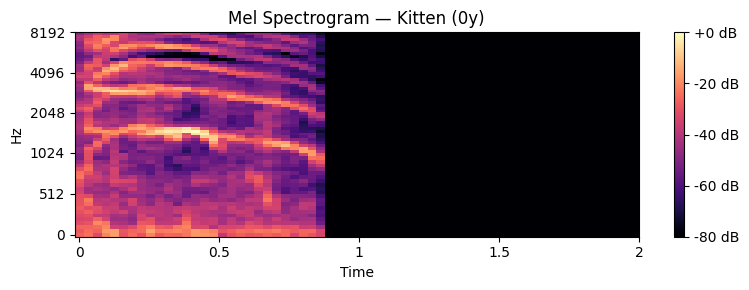

In [7]:
sample = df.sample(1, random_state=42).iloc[0]
y, sr = librosa.load(sample['path'], sr=SAMPLE_RATE, mono=True)
target_len = int(SAMPLE_RATE * DURATION)
if len(y) < target_len:
    y = np.pad(y, (0, target_len - len(y)))
else:
    y = y[:target_len]

mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                         n_fft=N_FFT, hop_length=HOP_LENGTH)
mel_db = librosa.power_to_db(mel, ref=np.max)

fig, ax = plt.subplots(figsize=(8, 3))
img = librosa.display.specshow(mel_db, x_axis='time', y_axis='mel',
                                sr=sr, hop_length=HOP_LENGTH, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title(f'Mel Spectrogram — {AGE_GROUPS[sample["label"]]} ({sample["age"]:.0f}y)')
plt.tight_layout()
os.makedirs('/content/drive/MyDrive/deep_purring/figures', exist_ok=True)
plt.savefig('/content/drive/MyDrive/deep_purring/figures/mel_spectrogram_example.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Dataset class

Loads a WAV, pads or truncates to 2 seconds, converts to a log-mel spectrogram. SpecAugment (frequency + time masking) is applied during training to help with the small dataset size.

In [8]:
class MelDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths    = paths
        self.labels   = labels
        self.augment  = augment
        self.tgt_len  = int(SAMPLE_RATE * DURATION)

    def __len__(self):
        return len(self.paths)

    def _load_mel(self, path):
        y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
        if len(y) < self.tgt_len:
            y = np.pad(y, (0, self.tgt_len - len(y)))
        else:
            y = y[:self.tgt_len]
        mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=N_MELS,
                                              n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
        mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)  # → [0, 1]
        return mel  # shape: (N_MELS, T)

    def __getitem__(self, idx):
        mel = self._load_mel(self.paths[idx])  # (64, T)
        if self.augment:
            # Frequency mask (up to 8 bins)
            f  = random.randint(0, 8)
            f0 = random.randint(0, N_MELS - f)
            mel[f0:f0 + f, :] = 0
            # Time mask (up to 10 % of frames)
            t  = random.randint(0, max(1, int(mel.shape[1] * 0.10)))
            t0 = random.randint(0, mel.shape[1] - t)
            mel[:, t0:t0 + t] = 0
        mel = torch.from_numpy(mel).unsqueeze(0)  # (1, 64, T)
        return mel, torch.tensor(self.labels[idx], dtype=torch.long)


## 8. DataLoader factory

In [9]:
def make_loaders(df: pd.DataFrame, seed: int):
    paths  = np.array(df['path'].tolist())
    labels = np.array(df['label'].tolist())
    groups = np.array(df['cat_id'].tolist())

    # Split off test set by cat
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=seed)
    train_val_idx, test_idx = next(gss_test.split(paths, labels, groups=groups))

    # Split train/val by cat (val = ~10% of full set → 1/9 of remaining 90%)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=1/9, random_state=seed)
    train_idx, val_idx = next(gss_val.split(
        paths[train_val_idx], labels[train_val_idx], groups=groups[train_val_idx]))

    X_tr  = paths[train_val_idx][train_idx];  y_tr  = labels[train_val_idx][train_idx]
    X_val = paths[train_val_idx][val_idx];    y_val = labels[train_val_idx][val_idx]
    X_te  = paths[test_idx];                  y_te  = labels[test_idx]

    # Verify no cat overlap
    cats_tr  = set(groups[train_val_idx][train_idx])
    cats_val = set(groups[train_val_idx][val_idx])
    cats_te  = set(groups[test_idx])
    assert cats_tr.isdisjoint(cats_val),  "Train/val cat overlap!"
    assert cats_tr.isdisjoint(cats_te),   "Train/test cat overlap!"
    assert cats_val.isdisjoint(cats_te),  "Val/test cat overlap!"

    train_dl = DataLoader(MelDataset(X_tr,  y_tr,  augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_dl   = DataLoader(MelDataset(X_val, y_val, augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print(f'Train: {len(X_tr)}  Val: {len(X_val)}  Test: {len(X_te)}  '
          f'(cats — tr: {len(cats_tr)}, val: {len(cats_val)}, te: {len(cats_te)})')
    return train_dl, val_dl, X_te, y_te

tr, va, xte, yte = make_loaders(df, seed=42)
print(f'Train batches: {len(tr)}  |  Val batches: {len(va)}  |  Test samples: {len(xte)}')

Train: 542  Val: 77  Test: 139  (cats — tr: 83, val: 11, te: 11)
Train batches: 17  |  Val batches: 3  |  Test samples: 139


## 9. Model architectures

**SmallCNN** — 3 conv layers trained from scratch on single-channel spectrograms.

**ResNet-18** — pretrained on ImageNet, first conv layer swapped for single-channel input, final layer replaced with a 3-class head.

In [10]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.head(self.features(x).flatten(1))


def make_resnet18():
    m = models.resnet18(weights='IMAGENET1K_V1')
    m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc    = nn.Linear(512, 3)
    return m


## 10. Training and evaluation utilities

In [11]:
def train(model, train_dl, val_dl, epochs=EPOCHS, lr=1e-3):
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    best_val, best_state = 0.0, None

    for epoch in tqdm(range(epochs), desc='Training'):
        model.train()
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(x), y).backward()
            optimizer.step()
        scheduler.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total   += y.size(0)
        val_acc = correct / total
        if val_acc > best_val:
            best_val   = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    print(f'Best val acc: {best_val:.3f}')
    return model


def evaluate(model, test_paths, test_labels):
    ds     = MelDataset(test_paths, test_labels, augment=False)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.extend(model(x.to(device)).argmax(1).cpu().numpy())
            trues.extend(y.numpy())
    return np.array(preds), np.array(trues)


In [12]:
def save_model(model, name):
    path = os.path.join(MODEL_DIR, f'{name}.pt')
    torch.save(model.state_dict(), path)
    print(f'Saved → {path}')

def load_model(model, name):
    path = os.path.join(MODEL_DIR, f'{name}.pt')
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    print(f'Loaded ← {path}')
    return model


## 11. Train / load Small CNN

In [13]:
random.seed(42); np.random.seed(42); torch.manual_seed(42)
tr42, va42, Xte42, yte42 = make_loaders(df, seed=42)

cnn_ckpt = os.path.join(MODEL_DIR, 'small_cnn_seed42.pt')
if os.path.exists(cnn_ckpt):
    print('=== Small CNN — loading from checkpoint ===')
    cnn = load_model(SmallCNN(), 'small_cnn_seed42')
else:
    print('=== Small CNN — training ===')
    cnn = SmallCNN()
    cnn = train(cnn, tr42, va42, epochs=EPOCHS, lr=1e-3)
    save_model(cnn, 'small_cnn_seed42')

cnn_preds, cnn_true = evaluate(cnn, Xte42, yte42)
print('\nSmall CNN — Test (seed 42):')
print(classification_report(cnn_true, cnn_preds, target_names=AGE_GROUPS))

Train: 542  Val: 77  Test: 139  (cats — tr: 83, val: 11, te: 11)
=== Small CNN — loading from checkpoint ===
Loaded ← /content/drive/MyDrive/deep_purring/saved_models/small_cnn_seed42.pt

Small CNN — Test (seed 42):
              precision    recall  f1-score   support

      Kitten       0.88      0.82      0.85        72
       Adult       0.71      0.65      0.68        55
      Senior       0.38      0.67      0.48        12

    accuracy                           0.74       139
   macro avg       0.66      0.71      0.67       139
weighted avg       0.77      0.74      0.75       139



## 12. Train / load ResNet-18

In [14]:
random.seed(42); np.random.seed(42); torch.manual_seed(42)

rn_ckpt = os.path.join(MODEL_DIR, 'resnet18_seed42.pt')
if os.path.exists(rn_ckpt):
    print('=== ResNet-18 — loading from checkpoint ===')
    resnet = load_model(make_resnet18(), 'resnet18_seed42')
else:
    print('=== ResNet-18 — training ===')
    resnet = make_resnet18()
    resnet = train(resnet, tr42, va42, epochs=EPOCHS, lr=1e-4)
    save_model(resnet, 'resnet18_seed42')

rn_preds, rn_true = evaluate(resnet, Xte42, yte42)
print('\nResNet-18 — Test (seed 42):')
print(classification_report(rn_true, rn_preds, target_names=AGE_GROUPS))

=== ResNet-18 — loading from checkpoint ===
Loaded ← /content/drive/MyDrive/deep_purring/saved_models/resnet18_seed42.pt

ResNet-18 — Test (seed 42):
              precision    recall  f1-score   support

      Kitten       0.79      0.21      0.33        72
       Adult       0.43      0.91      0.59        55
      Senior       0.80      0.33      0.47        12

    accuracy                           0.50       139
   macro avg       0.67      0.48      0.46       139
weighted avg       0.65      0.50      0.44       139



## 13. Multi-seed evaluation

In [15]:
RESULTS_DIR = '/content/drive/MyDrive/deep_purring/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

def multi_seed(model_fn, lr, label, results_name):
    results_path = os.path.join(RESULTS_DIR, f'{results_name}.csv')

    if os.path.exists(results_path):
        print(f'=== {label} — loading saved results ===')
        res = pd.read_csv(results_path)
        print(f'  Accuracy : {res["acc"].mean():.3f} ± {res["acc"].std():.3f}')
        print(f'  Macro F1 : {res["macro_f1"].mean():.3f} ± {res["macro_f1"].std():.3f}')
        return res

    rows = []
    for seed in RANDOM_SEEDS:
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        tr, va, Xte, yte = make_loaders(df, seed=seed)
        m = model_fn()
        m = train(m, tr, va, epochs=EPOCHS, lr=lr)
        p, t = evaluate(m, Xte, yte)
        rep  = classification_report(t, p, target_names=AGE_GROUPS, output_dict=True)
        rows.append({
            'seed':       seed,
            'acc':        accuracy_score(t, p),
            'macro_f1':   rep['macro avg']['f1-score'],
            'macro_prec': rep['macro avg']['precision'],
            'macro_rec':  rep['macro avg']['recall'],
        })
        print(f"  Seed {seed}: acc={rows[-1]['acc']:.3f}  macro_f1={rows[-1]['macro_f1']:.3f}")

    res = pd.DataFrame(rows)
    res.to_csv(results_path, index=False)
    print(f'\n{label} multi-seed summary:')
    print(f'  Accuracy : {res["acc"].mean():.3f} ± {res["acc"].std():.3f}')
    print(f'  Macro F1 : {res["macro_f1"].mean():.3f} ± {res["macro_f1"].std():.3f}')
    return res

print('=== Multi-seed: Small CNN ===')
cnn_multi = multi_seed(SmallCNN, lr=1e-3, label='Small CNN', results_name='cnn_multi_seed')

print('\n=== Multi-seed: ResNet-18 ===')
resnet_multi = multi_seed(make_resnet18, lr=1e-4, label='ResNet-18', results_name='resnet18_multi_seed')

=== Multi-seed: Small CNN ===
Train: 542  Val: 77  Test: 139  (cats — tr: 83, val: 11, te: 11)


Training:   0%|          | 0/60 [00:00<?, ?it/s]

Best val acc: 0.727
  Seed 42: acc=0.748  macro_f1=0.659
Train: 652  Val: 54  Test: 52  (cats — tr: 83, val: 11, te: 11)


Training:   0%|          | 0/60 [00:00<?, ?it/s]

Best val acc: 0.704
  Seed 7: acc=0.596  macro_f1=0.586
Train: 585  Val: 69  Test: 104  (cats — tr: 83, val: 11, te: 11)


...

Training:   0%|          | 0/60 [00:00<?, ?it/s]

Best val acc: 0.611
  Seed 7: acc=0.615  macro_f1=0.611
Train: 585  Val: 69  Test: 104  (cats — tr: 83, val: 11, te: 11)


Training:   0%|          | 0/60 [00:00<?, ?it/s]

Best val acc: 0.623
  Seed 123: acc=0.596  macro_f1=0.391

ResNet-18 multi-seed summary:
  Accuracy : 0.569 ± 0.064
  Macro F1 : 0.461 ± 0.130


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 14. Full model comparison

Combining seed-42 results from all experiments across the three notebooks.

In [16]:
# Seed-42 results from earlier experiments
prev = [
    ('SVM (RBF default)',       0.670, 0.527),
    ('SVM (best, C=10)',        0.711, 0.678),
    ('Logistic Regression',     0.753, 0.709),
    ('Neural Net (Adam+BN+L2)', 0.763, 0.740),
]

cnn_acc = accuracy_score(cnn_true, cnn_preds)
cnn_f1  = classification_report(cnn_true, cnn_preds, output_dict=True)['macro avg']['f1-score']
rn_acc  = accuracy_score(rn_true, rn_preds)
rn_f1   = classification_report(rn_true, rn_preds, output_dict=True)['macro avg']['f1-score']

rows = [(name, acc, f1) for name, acc, f1 in prev]
rows.append(('ResNet-18 (spectrograms)', rn_acc,  rn_f1))
rows.append(('Small CNN (spectrograms)', cnn_acc, cnn_f1))
rows.sort(key=lambda r: r[2])

summary = pd.DataFrame(rows, columns=['Model', 'Accuracy', 'Macro F1'])
summary['Accuracy'] = summary['Accuracy'].map('{:.3f}'.format)
summary['Macro F1'] = summary['Macro F1'].map('{:.3f}'.format)
print(summary.to_string(index=False))

                   Model Accuracy Macro F1
ResNet-18 (spectrograms)    0.496    0.463
       SVM (RBF default)    0.670    0.527
Small CNN (spectrograms)    0.741    0.671
        SVM (best, C=10)    0.711    0.678
     Logistic Regression    0.753    0.709
 Neural Net (Adam+BN+L2)    0.763    0.740


## 14b. Confusion matrices

Saved → /content/drive/MyDrive/deep_purring/figures/cm_small_cnn.png


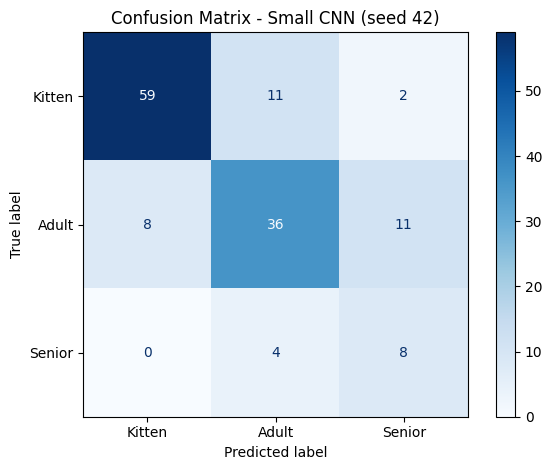

Saved → /content/drive/MyDrive/deep_purring/figures/cm_resnet18.png


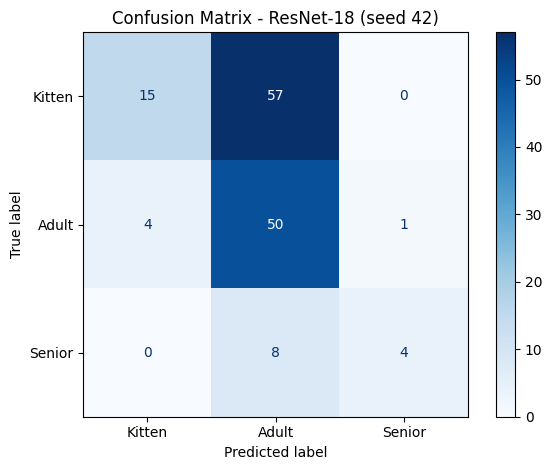

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

FIGURES_DIR = '/content/drive/MyDrive/deep_purring/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_confusion_matrix(y_true, y_preds, title, filename):
    cm = confusion_matrix(y_true, y_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=AGE_GROUPS)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved → {path}')
    plt.show()

save_confusion_matrix(cnn_true, cnn_preds,
                      'Confusion Matrix - Small CNN (seed 42)',
                      'cm_small_cnn.png')

save_confusion_matrix(rn_true, rn_preds,
                      'Confusion Matrix - ResNet-18 (seed 42)',
                      'cm_resnet18.png')

## 15. Demo

Run the cell to test the trained SmallCNN on a random file from the dataset. It picks a file, predicts the age group, and checks against the true label.

In [18]:
def predict_age_group(wav_path: str, model_name: str = 'small_cnn_seed42'):
    model = load_model(SmallCNN(), model_name)
    model.eval()

    y, _ = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
    target_len = int(SAMPLE_RATE * DURATION)
    y = np.pad(y, (0, target_len - len(y))) if len(y) < target_len else y[:target_len]

    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=N_MELS,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
    mel = torch.from_numpy(mel).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        logits = model(mel.to(device)).squeeze(0)
    probs = torch.softmax(logits, dim=0).cpu().numpy()
    pred_idx = int(logits.argmax().item())

    return AGE_GROUPS[pred_idx], probs


# pick a random file from the dataset and check against true label
sample = df.sample(1, random_state=None).iloc[0]
wav_path   = sample['path']
true_label = AGE_GROUPS[sample['label']]
true_age   = sample['age']

pred_label, probs = predict_age_group(wav_path)
correct = pred_label == true_label

print(f'File:      {os.path.basename(wav_path)}')
print(f'True:      {true_age:.1f} years ({true_label})')
print(f'Predicted: {pred_label}  {"CORRECT" if correct else "WRONG"}')
print('Probabilities:')
for name, p in zip(AGE_GROUPS, probs):
    marker = ' <--' if name == pred_label else ''
    print(f'  {name:8s}: {p:.2%}{marker}')

Loaded ← /content/drive/MyDrive/deep_purring/saved_models/small_cnn_seed42.pt
File:      6Y-002B-M3-11.wav
True:      6.0 years (Adult)
Predicted: Adult  CORRECT
Probabilities:
  Kitten  : 0.67%
  Adult   : 80.42% <--
  Senior  : 18.91%
